<a href="https://colab.research.google.com/github/Asfiashub/Mini-Projects/blob/main/ML/K_means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

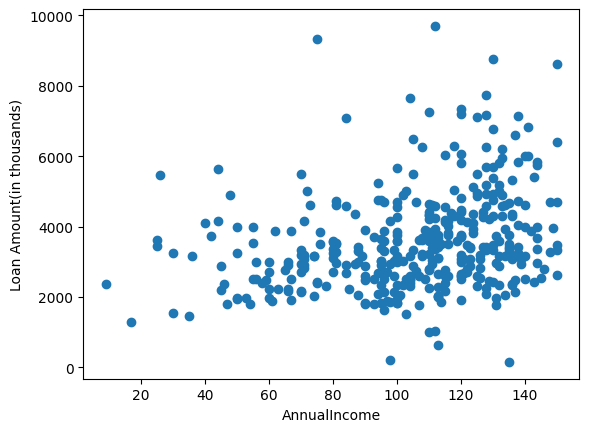

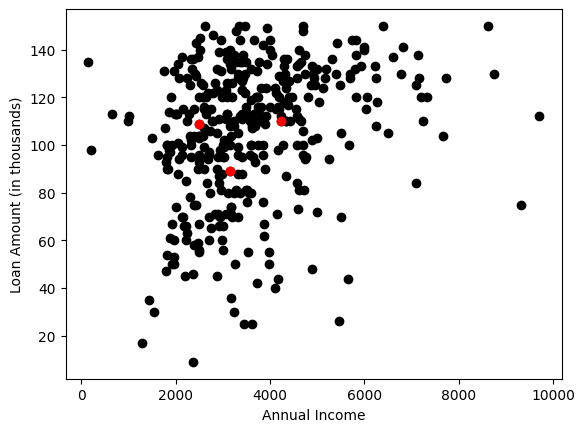

462.52689505108975
413.48696598883816
164.69118158587673
241.75650104316816
284.41335268050597
211.50041280045707
223.00303487546444
187.01068731505586
98.01161657776196
52.84741626127729
98.54724443834282
90.64953219227577
18.274686272279013
9.21023994083339
18.345487493007468
46.27013250786139
0.0
         LoanAmount  ApplicantIncome
Cluster                             
1        109.756410      4033.596154
2        119.488372      6512.767442
3         97.472527      2497.972527


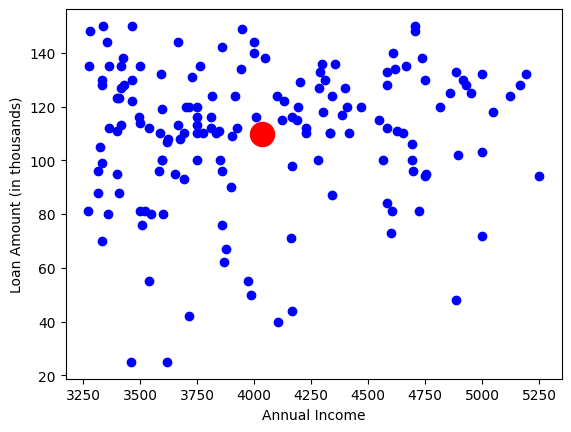

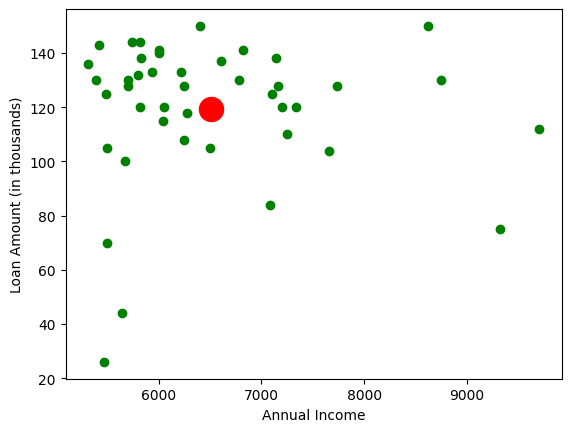

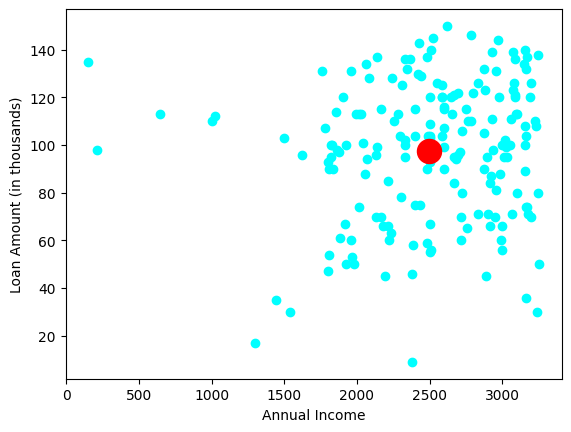

In [9]:
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt
data= pd.read_csv('/content/clustering (2).csv')
data.head()

X=data[["LoanAmount","ApplicantIncome"]].copy()
#visualize data points
plt.scatter(X["LoanAmount"],X["ApplicantIncome"])
plt.xlabel("AnnualIncome")
plt.ylabel("Loan Amount(in thousands)")
plt.show()
K=3 #no.of clusters
#select random observations as centroids
Centroids = (X.sample(n=K))
plt.scatter(X["ApplicantIncome"],X["LoanAmount"],c='black')
plt.scatter(Centroids["ApplicantIncome"],Centroids["LoanAmount"],c='red')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount (in thousands)')
plt.show()
diff= 1
j=0
while(diff!=0):
  XD=X
  i=1
  for index1,row_c in Centroids.iterrows():
    ED=[]
    for index2,row_d in XD.iterrows():
      d1=(row_c["ApplicantIncome"]-row_d["ApplicantIncome"])**2
      d2=(row_c["LoanAmount"]-row_d["LoanAmount"])**2
      d=np.sqrt(d1+d2)
      ED.append(d)
    X[i]=ED
    i=i+1
  C=[]

  for index,row in X.iterrows():

    min_dist=row[1]
    pos=1
    for i in range(K):
      if row[i+1]<min_dist:
        min_dist=row[i+1]
        pos=i+1
    C.append(pos)
  X["Cluster"]=C
  Centroids_new = X.groupby(["Cluster"]).mean()[["LoanAmount","ApplicantIncome"]]
  if j==0:
    diff=1
    j=j+1
  else:
    diff = (Centroids_new['LoanAmount'] - Centroids['LoanAmount']).sum() + (Centroids_new['ApplicantIncome'] - Centroids['ApplicantIncome']).sum()
    print(diff.sum())

  Centroids=X.groupby(["Cluster"]).mean()[["LoanAmount","ApplicantIncome"]]
  color=['blue','green','cyan']
print(Centroids)
X.head()

for k in range(K):
  data=X[X["Cluster"]==k+1]
  plt.scatter(data["ApplicantIncome"],data["LoanAmount"],c=color[k])
  plt.scatter(Centroids["ApplicantIncome"][k+1],Centroids["LoanAmount"][k+1],s=300,c='red')
  plt.xlabel("Annual Income")
  plt.ylabel("Loan Amount (in thousands)")
  plt.show()